In [10]:
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve

In [11]:
# 1. Load Data (Replace with your actual paths if needed)
train_df = pd.read_csv(r"C:\Tata AI Hackathon\Tata-AI-Hackathon\dataset\train.csv")
test_df = pd.read_csv(r"C:\Tata AI Hackathon\Tata-AI-Hackathon\dataset\test.csv")

In [12]:
# 2. Feature Engineering Function
def engineer_features(df):
    df_engineered = df.copy()
    feature_cols = [f'X{i}' for i in range(1, 50)]
    existing_cols = [c for c in feature_cols if c in df.columns]
    
    # Deltas
    for i in range(1, 49):
        col_current = f'X{i}'
        col_next = f'X{i+1}'
        if col_current in existing_cols and col_next in existing_cols:
            df_engineered[f'delta_{i}'] = df_engineered[col_next] - df_engineered[col_current]
            
    # Row-wise Stats
    df_engineered['X_mean'] = df_engineered[existing_cols].mean(axis=1)
    df_engineered['X_std'] = df_engineered[existing_cols].std(axis=1)
    df_engineered['X_max'] = df_engineered[existing_cols].max(axis=1)
    df_engineered['X_min'] = df_engineered[existing_cols].min(axis=1)
    df_engineered['X_range'] = df_engineered['X_max'] - df_engineered['X_min']
    
    return df_engineered

print("Engineering features...")
train_engineered = engineer_features(train_df)
test_engineered = engineer_features(test_df)

X_train = train_engineered.drop(columns=['CoilID', 'Y'])
y_train = train_engineered['Y']
X_test = test_engineered.drop(columns=['CoilID'])
test_ids = test_engineered['CoilID']

Engineering features...


In [13]:
# 3. Model Setup 
# HistGradientBoosting handles missing values natively and we use class_weight to handle imbalance
model = HistGradientBoostingClassifier(
    max_iter=400,
    class_weight='balanced',
    l2_regularization=1.5,
    max_depth=5, 
    random_state=42
)

In [14]:
# 4. Out-Of-Fold (OOF) Cross-Validation
print("Running Stratified K-Fold CV...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X_train))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    model.fit(X_tr, y_tr)
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]

Running Stratified K-Fold CV...


In [15]:
# 5. Find the Optimal Threshold using OOF predictions (Much safer!)
precisions, recalls, thresholds = precision_recall_curve(y_train, oof_preds)

# We want 100% recall (or extremely close to it)
valid_thresholds = thresholds[recalls[:-1] >= 0.999] 
best_threshold = valid_thresholds[-1] if len(valid_thresholds) > 0 else 0.5
final_threshold = max(0.0001, best_threshold - 0.002) # Smaller safety margin since OOF is reliable

print(f"Calculated optimal threshold (from CV): {best_threshold:.6f}")
print(f"Applying final threshold: {final_threshold:.6f}")

Calculated optimal threshold (from CV): 0.000011
Applying final threshold: 0.000100


In [16]:
# 6. Retrain on the FULL dataset for final predictions
print("Retraining on full dataset...")
model.fit(X_train, y_train)
test_probs = model.predict_proba(X_test)[:, 1]

Retraining on full dataset...


In [17]:
# 7. Apply Threshold and Save
test_preds = (test_probs >= final_threshold).astype(int)

submission = pd.DataFrame({
    'CoilID': test_ids,
    'Y': test_preds
})

submission.to_csv('expected_submission_v3.csv', index=False)
print("✅ Submission saved as 'expected_submission_v3.csv'")
print(f"Total defects predicted in test set: {test_preds.sum()} out of {len(test_preds)}")

✅ Submission saved as 'expected_submission_v3.csv'
Total defects predicted in test set: 176 out of 339


Calculating feature importance (this might take a few seconds)...

--- TOP 5 MOST IMPORTANT FEATURES ---
X1          0.0
delta_16    0.0
delta_26    0.0
delta_25    0.0
delta_24    0.0
dtype: float64


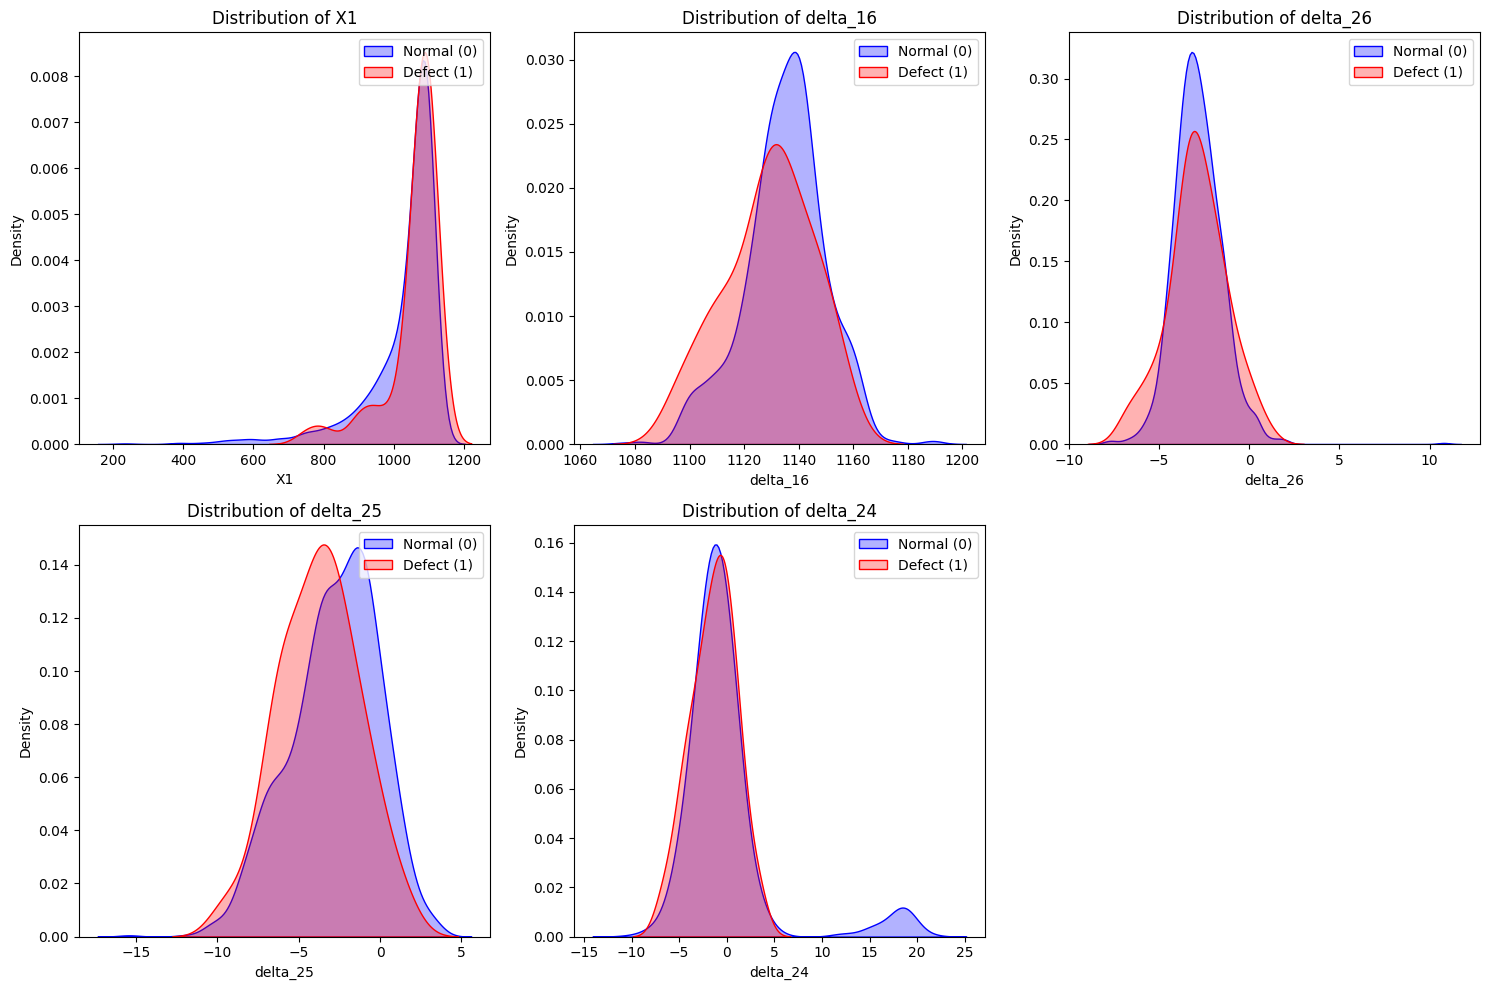

In [18]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

print("Calculating feature importance (this might take a few seconds)...")
# Ask the model what features it relied on the most
result = permutation_importance(model, X_train, y_train, n_repeats=5, random_state=42, n_jobs=-1)

# Rank them
importances = pd.Series(result.importances_mean, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(5)

print("\n--- TOP 5 MOST IMPORTANT FEATURES ---")
print(top_features)

# Draw pictures (distributions) of the top 5 features
plt.figure(figsize=(15, 10))
for i, col in enumerate(top_features.index, 1):
    plt.subplot(2, 3, i)
    # Plot normal coils in blue
    sns.kdeplot(data=train_engineered[train_engineered['Y'] == 0], x=col, label='Normal (0)', fill=True, color='blue', alpha=0.3)
    # Plot defective coils in red
    sns.kdeplot(data=train_engineered[train_engineered['Y'] == 1], x=col, label='Defect (1)', fill=True, color='red', alpha=0.3)
    plt.title(f"Distribution of {col}")
    plt.legend()

plt.tight_layout()
plt.show()